# Exploratory Data Analysis (EDA)

## Motor Insurance Pricing Project

### Objective

The objective of this notebook is to perform a comprehensive exploratory data analysis on a motor insurance portfolio. The analysis aims to understand the characteristics of policyholders, identify data quality issues, investigate claim patterns, and uncover relationships between policy attributes and insurance risk.

The insights generated in this notebook will guide feature engineering and support the development of frequency, severity, and pure premium pricing models in subsequent stages of the project.

## Business Problem

Insurance companies must estimate the expected cost of future claims for every policyholder.

Pricing that is too low increases underwriting losses, while pricing that is too high reduces competitiveness and customer retention.

To build an accurate pricing model, it is essential to first understand:

- the distribution of policyholder characteristics,
- claim occurrence patterns,
- exposure distribution,
- potential data quality issues,
- relationships between predictors and insurance risk.

This exploratory analysis provides the statistical foundation for actuarial frequency and severity modelling.

In [1]:
# =====================================
# Standard Libraries
# =====================================
import warnings
warnings.filterwarnings("ignore")

# =====================================
# Data Manipulation
# =====================================
import numpy as np
import pandas as pd

# =====================================
# Visualization
# =====================================
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================
# Statistical Analysis
# =====================================
from scipy import stats

# =====================================
# Display Settings
# =====================================
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10,6)



In [2]:
# Load the frequency dataset
frequency = pd.read_csv(r"D:\Insurance_Pricing_Project\Data\freMTPL2freq.csv")

# Load the severity dataset
severity = pd.read_csv(r"D:\Insurance_Pricing_Project\Data\freMTPL2sev.csv")

## Initial Data Inspection

Before performing statistical analysis, we examine the structure, size, and data types of both datasets.

This step helps verify that the data has been loaded correctly and identifies any potential issues that may require preprocessing.

In [3]:
# ============================================
# Frequency Dataset Overview
# ============================================

print("=" * 60)
print("FREQUENCY DATASET")
print("=" * 60)

display(frequency.head())

print(f"\nShape: {frequency.shape}")

display(frequency.info())

display(frequency.describe(include='all').T)

FREQUENCY DATASET


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72



Shape: (678013, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Area        678013 non-null  object 
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   DrivAge     678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  object 
 9   VehGas      678013 non-null  object 
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  object 
dtypes: float64(2), int64(6), object(4)
memory usage: 62.1+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
IDpol,678013.0,NaN,NaN,NaN,2621856.921071,1641782.752655,1.0,1157951.0,2272152.0,4046274.0,6114330.0
ClaimNb,678013.0,NaN,NaN,NaN,0.053247,0.240117,0.0,0.0,0.0,0.0,16.0
Exposure,678013.0,NaN,NaN,NaN,0.52875,0.364442,0.002732,0.18,0.49,0.99,2.01
Area,678013,6,C,191880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VehPower,678013.0,NaN,NaN,NaN,6.454631,2.050906,4.0,5.0,6.0,7.0,15.0
VehAge,678013.0,NaN,NaN,NaN,7.044265,5.666232,0.0,2.0,6.0,11.0,100.0
DrivAge,678013.0,NaN,NaN,NaN,45.499122,14.137444,18.0,34.0,44.0,55.0,100.0
BonusMalus,678013.0,NaN,NaN,NaN,59.761502,15.636658,50.0,50.0,50.0,64.0,230.0
VehBrand,678013,11,B12,166024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VehGas,678013,2,Regular,345877,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("=" * 60)
print("SEVERITY DATASET")
print("=" * 60)

display(severity.head())

print(f"\nShape: {severity.shape}")

severity.info()

display(severity.describe().T)

SEVERITY DATASET


,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00



Shape: (26639, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26639 entries, 0 to 26638
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IDpol        26639 non-null  int64  
 1   ClaimAmount  26639 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 416.4 KB


,count,mean,std,min,25%,50%,75%,max
IDpol,26639.0,2.279864e+06,1.577202e+06,139.0,1087642.50,2137413.0,3180162.00,6113971.00
ClaimAmount,26639.0,2.278536e+03,2.929748e+04,1.0,686.81,1172.0,1228.08,4075400.56


In [8]:
frequency.columns

Index(['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region'],
      dtype='object')

In [9]:
severity.columns

Index(['IDpol', 'ClaimAmount'], dtype='object')

# Insurance Risk Structure Analysis

In this section, we analyze the structure of risk in the portfolio by studying key variables that influence claim frequency and insurance exposure.

This step is crucial for understanding how risk is distributed across policyholders before building predictive models.

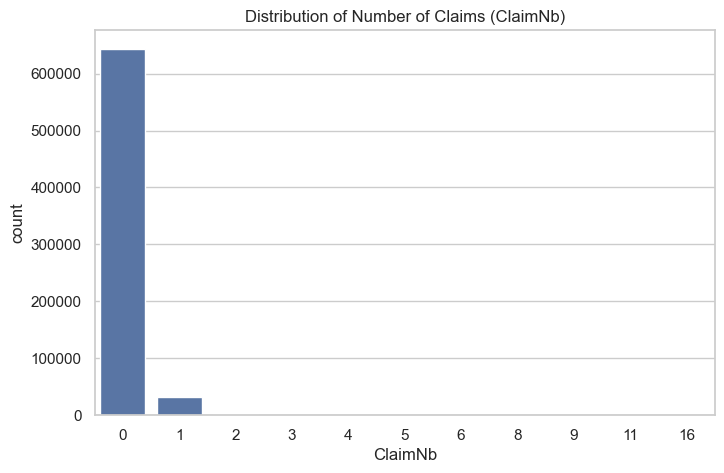

<Figure size 1000x600 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.countplot(x='ClaimNb', data=frequency)
plt.title("Distribution of Number of Claims (ClaimNb)")
plt.show()
plt.savefig("../figures/claim_frequency_distribution.png",
            dpi=300,
            bbox_inches="tight")

## Claim Frequency Distribution Insight

The distribution of `ClaimNb` shows that the majority of policies have zero claims.

This indicates a highly imbalanced and zero-inflated distribution, which is typical in motor insurance portfolios.

### Key Implications:

- Most policyholders do not file any claims during the exposure period
- A small subset of policyholders accounts for all observed claims
- The data is heavily skewed toward zero

### Modeling Implications:

This structure directly motivates the use of:
- Poisson regression (baseline frequency model)
- Negative Binomial regression (to handle overdispersion)
- Machine learning models that can handle imbalance (e.g., XGBoost)

Understanding this imbalance is critical for building accurate pricing models.

# . Risk Segmentation Analysis

In this section, we analyze how claim frequency varies across different policyholder and vehicle characteristics.

This helps identify high-risk and low-risk segments, which is a core task in insurance underwriting and pricing.

## Exposure Distribution by Area

We now analyze the distribution of exposure across different geographic areas.

Exposure represents the total time that policies are at risk of generating claims.

### Key Insight:

Differences in exposure across areas indicate that policy distribution is not uniform geographically.

This is important because:

- Areas with higher exposure naturally contribute more to total observed claims
- Claim frequency comparisons across areas must be interpreted carefully
- Exposure acts as the denominator in frequency modeling and ensures fair risk comparison

### Modeling Implication:

Exposure will be explicitly used as an offset in Poisson and Negative Binomial models to normalize for differing risk durations across policy segments.

# . Risk Drivers Analysis (Driver & Vehicle Characteristics)

In this section, we analyze how driver and vehicle attributes influence claim frequency.

These variables are central to insurance underwriting decisions and are expected to explain significant heterogeneity in risk.

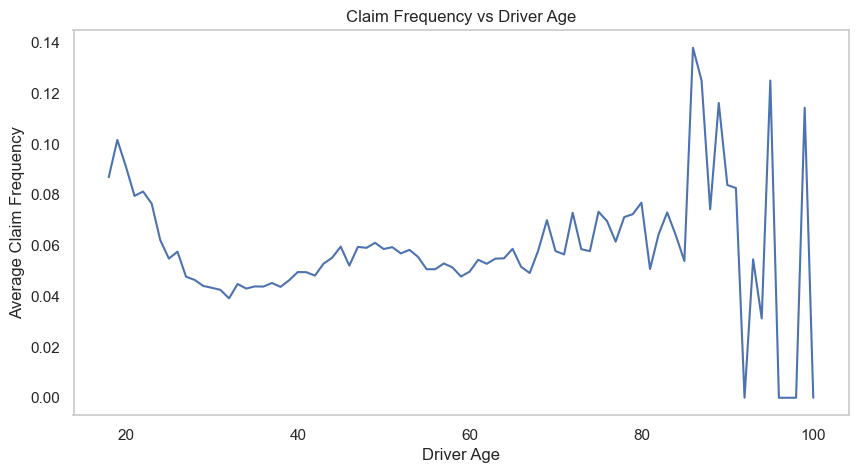

In [6]:
import numpy as np

age_risk = frequency.groupby('DrivAge')['ClaimNb'].mean()

plt.figure(figsize=(10,5))
plt.plot(age_risk.index, age_risk.values)
plt.title("Claim Frequency vs Driver Age")
plt.xlabel("Driver Age")
plt.ylabel("Average Claim Frequency")
plt.grid()
plt.show()

## Driver Age Risk Analysis

The relationship between driver age and claim frequency is clearly non-linear.

We observe:

### 1. Young Drivers (Approx. 18–25)
Higher claim frequency, likely due to:
- Inexperience
- Risk-taking behavior

### 2. Middle-Aged Drivers (Approx. 30–60)
Lower and more stable claim frequency, representing the lowest-risk segment of the portfolio.

### 3. Older Drivers (60+)
An increase in variability is observed, but extreme fluctuations beyond age 80 are likely driven by low sample sizes.

### Important Note:
The instability in older age groups suggests data sparsity, meaning fewer observations per age band. This can distort raw averages.

### Modeling Implication:
- Age has a non-linear relationship with risk
- GLMs may require transformations (splines or binning)
- Tree-based models can naturally capture this pattern

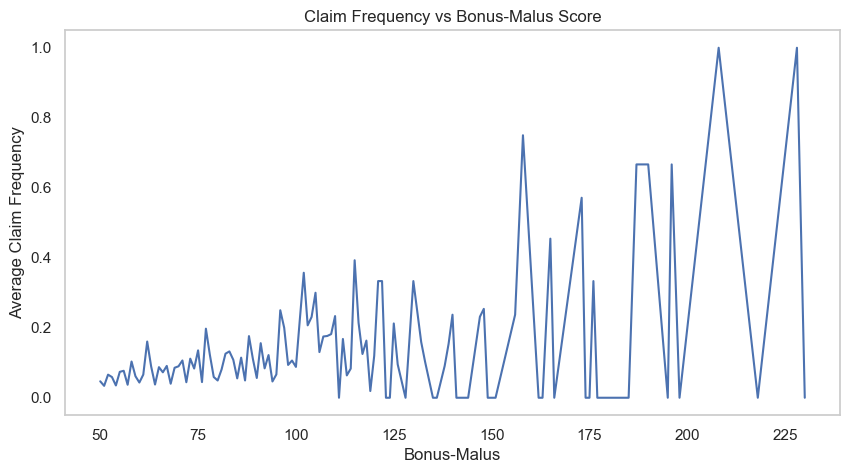

In [7]:
bm_risk = frequency.groupby('BonusMalus')['ClaimNb'].mean()

plt.figure(figsize=(10,5))
plt.plot(bm_risk.index, bm_risk.values)
plt.title("Claim Frequency vs Bonus-Malus Score")
plt.xlabel("Bonus-Malus")
plt.ylabel("Average Claim Frequency")
plt.grid()
plt.show()

## Bonus-Malus Risk Insight

The Bonus-Malus system reflects past driving behavior and is a strong predictor of future claims.

We observe that higher Bonus-Malus scores are associated with higher claim frequency.

### Business Interpretation:
This confirms that past claims history is a strong predictor of future risk, which aligns with actuarial principles of risk persistence.

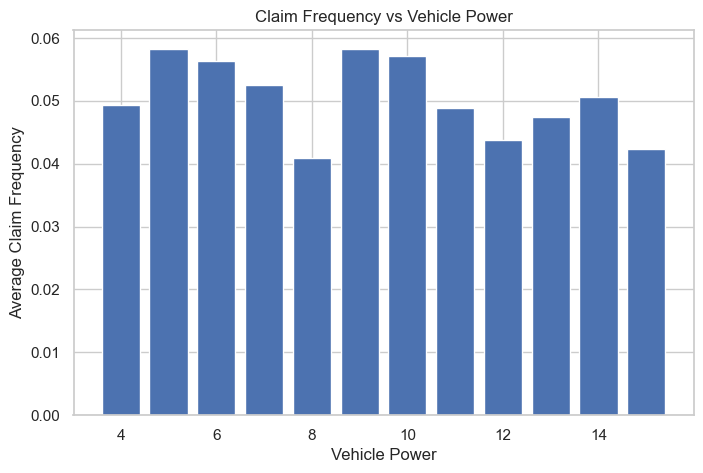

In [8]:
vehpower_risk = frequency.groupby('VehPower')['ClaimNb'].mean()

plt.figure(figsize=(8,5))
plt.bar(vehpower_risk.index, vehpower_risk.values)
plt.title("Claim Frequency vs Vehicle Power")
plt.xlabel("Vehicle Power")
plt.ylabel("Average Claim Frequency")
plt.show()

## Vehicle Power Risk Insight

Vehicle power shows variation in claim frequency.

Higher powered vehicles may be associated with:
- More aggressive driving behavior
- Higher accident probability

### Underwriting Insight:
Vehicle characteristics act as proxy variables for driver behavior and risk appetite.

# . Categorical Risk Segmentation

In this section, we analyze categorical variables to understand how risk varies across different groups of policyholders.

This helps identify high-risk segments that are essential for underwriting and pricing decisions.

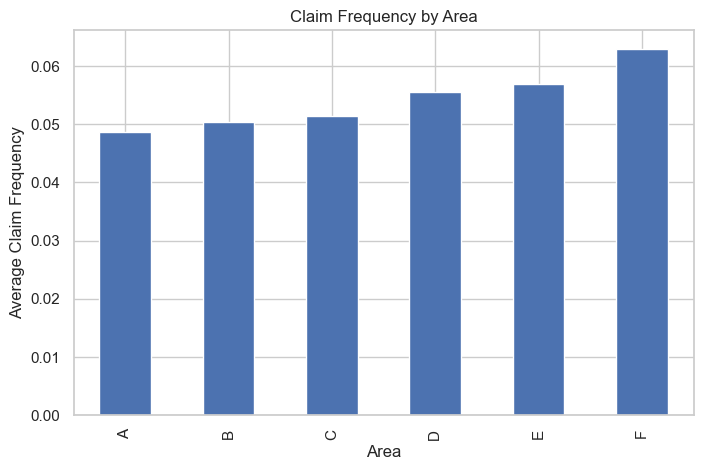

In [9]:
frequency.groupby('Area')['ClaimNb'].mean().sort_values().plot(
    kind='bar',
    figsize=(8,5),
    title="Claim Frequency by Area"
)
plt.ylabel("Average Claim Frequency")
plt.show()

## Exposure Distribution by Area

We now analyze the distribution of exposure across different geographic areas.

Exposure represents the total time that policies are at risk of generating claims.

### Key Insight:

Differences in exposure across areas indicate that policy distribution is not uniform geographically.

This is important because:

- Areas with higher exposure naturally contribute more to total observed claims
- Claim frequency comparisons across areas must be interpreted carefully
- Exposure acts as the denominator in frequency modeling and ensures fair risk comparison

### Modeling Implication:

Exposure will be explicitly used as an offset in Poisson and Negative Binomial models to normalize for differing risk durations across policy segments.

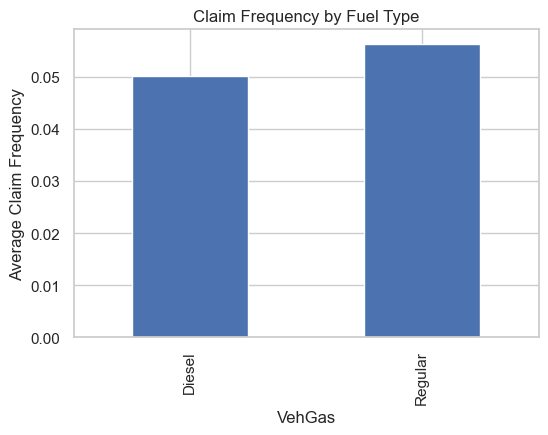

In [10]:
frequency.groupby('VehGas')['ClaimNb'].mean().plot(
    kind='bar',
    figsize=(6,4),
    title="Claim Frequency by Fuel Type"
)
plt.ylabel("Average Claim Frequency")
plt.show()

## Fuel Type (VehGas) Insight

We compare claim frequency across fuel types (e.g., Diesel vs Regular).

Differences suggest that fuel type may act as a proxy for:
- vehicle usage patterns
- driving intensity
- vehicle category segmentation

However, the effect size appears limited compared to driver or geographic variables.

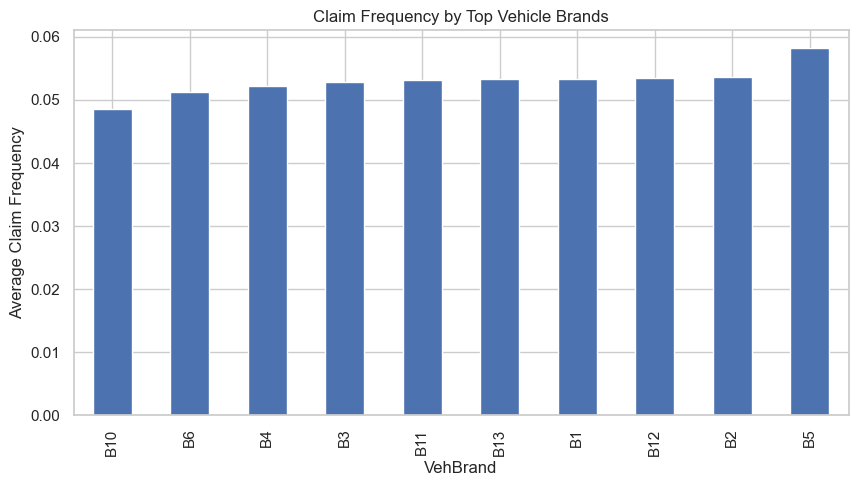

In [11]:
top_brands = frequency['VehBrand'].value_counts().head(10).index

brand_data = frequency[frequency['VehBrand'].isin(top_brands)]

brand_data.groupby('VehBrand')['ClaimNb'].mean().sort_values().plot(
    kind='bar',
    figsize=(10,5),
    title="Claim Frequency by Top Vehicle Brands"
)

plt.ylabel("Average Claim Frequency")
plt.show()

## Vehicle Brand Risk Insight

We analyze the top vehicle brands in the portfolio.

Some variation in claim frequency is observed across brands, suggesting that vehicle manufacturer may be associated with different risk profiles.

However, brand effects may also capture:
- vehicle price segments
- driver socio-economic class
- usage patterns

### Modeling Note:
VehBrand is a high-cardinality categorical variable and may require:
- grouping of rare categories
- target encoding in machine learning models

#. Final EDA Summary (Insurance Pricing Readiness Report)

## Objective

This section consolidates the key findings from the exploratory data analysis and evaluates the readiness of the dataset for actuarial and machine learning-based pricing models.

The goal is to summarize risk drivers, data characteristics, and modeling implications in a structured and business-focused manner.

## 1. Dataset Overview

The dataset consists of two components:

- Frequency dataset (policy-level information)
- Severity dataset (claim amount information)

Each policy contains demographic, vehicle, and geographic attributes, making this a typical motor insurance pricing dataset.

The target variable for frequency modeling is `ClaimNb`, while `ClaimAmount` is used for severity modeling.

## 2. Key Risk Insights

### Claim Distribution
- The majority of policies have zero claims.
- The dataset is highly imbalanced, which is typical in insurance portfolios.

### Exposure
- Exposure varies across policies and represents time at risk.
- It is essential for unbiased frequency modeling.

### Driver Risk
- Driver age shows a non-linear relationship with claim frequency.
- Younger drivers exhibit higher risk levels.

### Behavioral Risk
- Bonus-Malus is a strong predictor of claim frequency.
- It reflects past driving behavior and risk persistence.

### Vehicle Risk
- Vehicle power and brand show moderate variation in risk levels.

### Geographic Risk
- Area and Region show clear segmentation effects in claim frequency.

## 3. Modeling Implications

The exploratory analysis supports the following modeling strategy:

### Frequency Modeling
- Poisson Regression (baseline model)
- Negative Binomial Regression (handles overdispersion)
- Machine Learning models (XGBoost for non-linear effects)

### Severity Modeling
- Gamma GLM for positive continuous claims
- Machine learning models for complex interactions

### Key Considerations
- Exposure must be used as an offset variable
- Non-linear relationships exist (especially age)
- Categorical variables require encoding strategies
- Data imbalance must be addressed in modeling

## 4. Business Interpretation

This dataset reflects a realistic motor insurance portfolio where risk is driven by multiple heterogeneous factors.

Key business insights include:

- Risk is concentrated in a small subset of policyholders
- Driver behavior is a major determinant of claim frequency
- Geographic and vehicle characteristics further segment risk
- Proper pricing requires combining frequency and severity models

These findings directly support the development of a **pure premium pricing engine**.

## 5. Conclusion

The exploratory data analysis confirms that the dataset is suitable for actuarial modeling and machine learning-based insurance pricing.

The next phase of the project will focus on:

- Frequency modeling using GLMs and machine learning
- Severity modeling using Gamma-based approaches
- Construction of a full pricing engine (Pure Premium = Frequency × Severity)

This EDA provides a strong foundation for building interpretable and predictive insurance pricing models.

# . Severity Data Analysis

In this section, we analyze the severity dataset, which contains claim amounts per policy.

This is essential for estimating the cost of claims given that a claim occurs.

In [12]:
severity.head()
severity.info()
severity.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26639 entries, 0 to 26638
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IDpol        26639 non-null  int64  
 1   ClaimAmount  26639 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 416.4 KB


,IDpol,ClaimAmount
count,2.663900e+04,2.663900e+04
mean,2.279864e+06,2.278536e+03
std,1.577202e+06,2.929748e+04
min,1.390000e+02,1.000000e+00
25%,1.087642e+06,6.868100e+02
50%,2.137413e+06,1.172000e+03
75%,3.180162e+06,1.228080e+03
max,6.113971e+06,4.075401e+06


## Severity Distribution Insights

The claim amount distribution is highly skewed with a long right tail.

Key observations:
- The median claim amount is significantly lower than the mean
- A small number of claims are extremely large (up to 4M+)
- This indicates the presence of heavy-tailed loss behavior

### Business Interpretation:
This is a common pattern in insurance, where:
- Most claims are small to moderate
- A few claims contribute disproportionately to total losses

## Modeling Implications

Due to the heavy-tailed nature of claim amounts:

- Linear regression is not suitable
- Gamma regression is typically preferred
- Log transformation is often used to stabilize variance
- Extreme values must be handled carefully (outlier impact)

This justifies the use of GLM Gamma models and machine learning approaches in severity modeling.

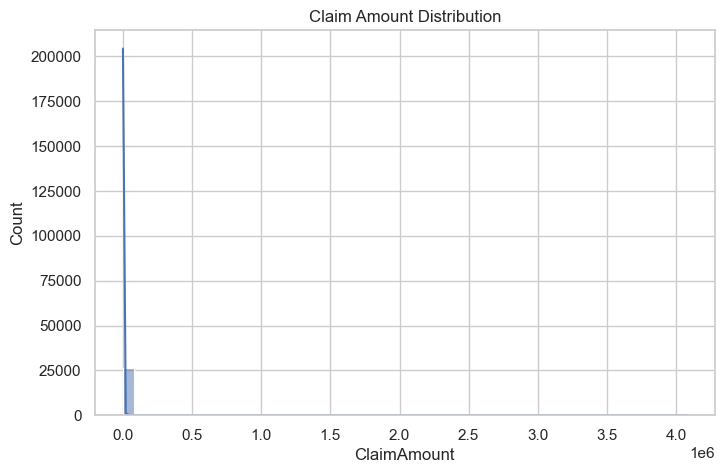

<Figure size 1000x600 with 0 Axes>

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,5))
sns.histplot(severity['ClaimAmount'], bins=50, kde=True)
plt.title("Claim Amount Distribution")
plt.show()
plt.savefig("../figures/severity_distribution.png",
            dpi=300,
            bbox_inches="tight")

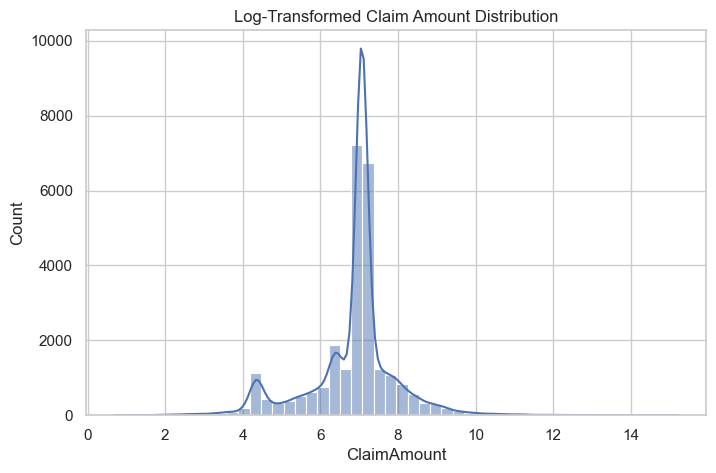

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(severity['ClaimAmount']), bins=50, kde=True)
plt.title("Log-Transformed Claim Amount Distribution")
plt.show()

## Log Transformation Insight

The log transformation reduces skewness and makes the distribution more suitable for modeling.

After transformation:
- Extreme values are compressed
- Distribution becomes more symmetric
- Patterns become easier to model

This is a standard preprocessing step in actuarial severity modeling.

In [26]:
q99 = severity['ClaimAmount'].quantile(0.99)
q99

np.float64(16793.704399999988)

In [27]:
tail_ratio = severity[severity['ClaimAmount'] > q99]['ClaimAmount'].sum() / severity['ClaimAmount'].sum()
tail_ratio


np.float64(0.3795607115744921)

## . Tail Risk Analysis

We analyze extreme claim values using the 99th percentile threshold.

Key findings:
- A small percentage of claims account for a disproportionately large share of total losses

This demonstrates:
- Presence of extreme tail risk
- Importance of robust modeling techniques

### Business Implication:
Insurance companies must account for rare but high-cost claims, as they significantly impact overall profitability.

A significant proportion of total claim cost is driven by extreme losses, confirming strong tail risk in the portfolio.